# Explorative Analyse

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Frauen haben bei einem Herzinfarkt atypische schmerzen

In [17]:
# Hereinladen der Daten
df = pd.read_csv('heart.csv')

# Eine Kopie für die Visualisierung erstellen (mit Text statt Zahlen)
# Das ist wichtig, damit dein Dozent in der Grafik "Männlich" liest statt "1"
df_vis = df.copy()

# Labels umbenennen für bessere Lesbarkeit
df_vis['sex'] = df_vis['sex'].map({1: 'Männlich', 0: 'Weiblich'})
df_vis['target'] = df_vis['target'].map({1: 'Herzkrankheit', 0: 'Gesund'})
df_vis['cp'] = df_vis['cp'].map({
    0: 'Typische Angina',
    1: 'Atypische Angina',
    2: 'Nicht-anginöser Schmerz',
    3: 'Asymptomatisch'
})

# Generelles Design der Plots setzen
sns.set_theme(style="whitegrid")

C:\Users\jaegg\AppData\Local\Temp\ipykernel_20020\3381038168.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='target', data=df_vis, palette='pastel')


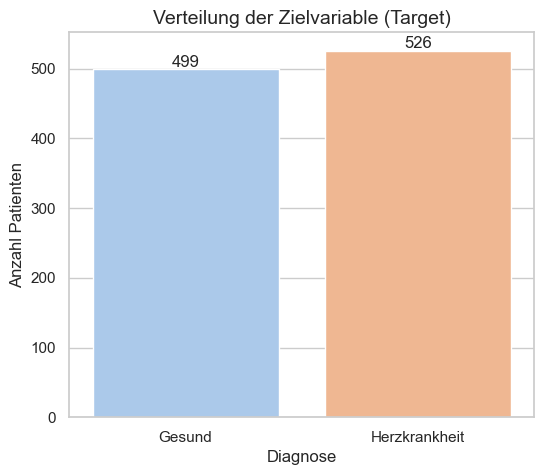

In [18]:
plt.figure(figsize=(6, 5))
ax = sns.countplot(x='target', data=df_vis, palette='pastel')

plt.title('Verteilung der Zielvariable (Target)', fontsize=14)
plt.xlabel('Diagnose', fontsize=12)
plt.ylabel('Anzahl Patienten', fontsize=12)

# Zahlen auf die Balken schreiben
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

C:\Users\jaegg\AppData\Local\Temp\ipykernel_20020\2849710715.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='age', data=df_vis, palette='Set2', ax=axes[0])
C:\Users\jaegg\AppData\Local\Temp\ipykernel_20020\2849710715.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='chol', data=df_vis, palette='Set2', ax=axes[1])


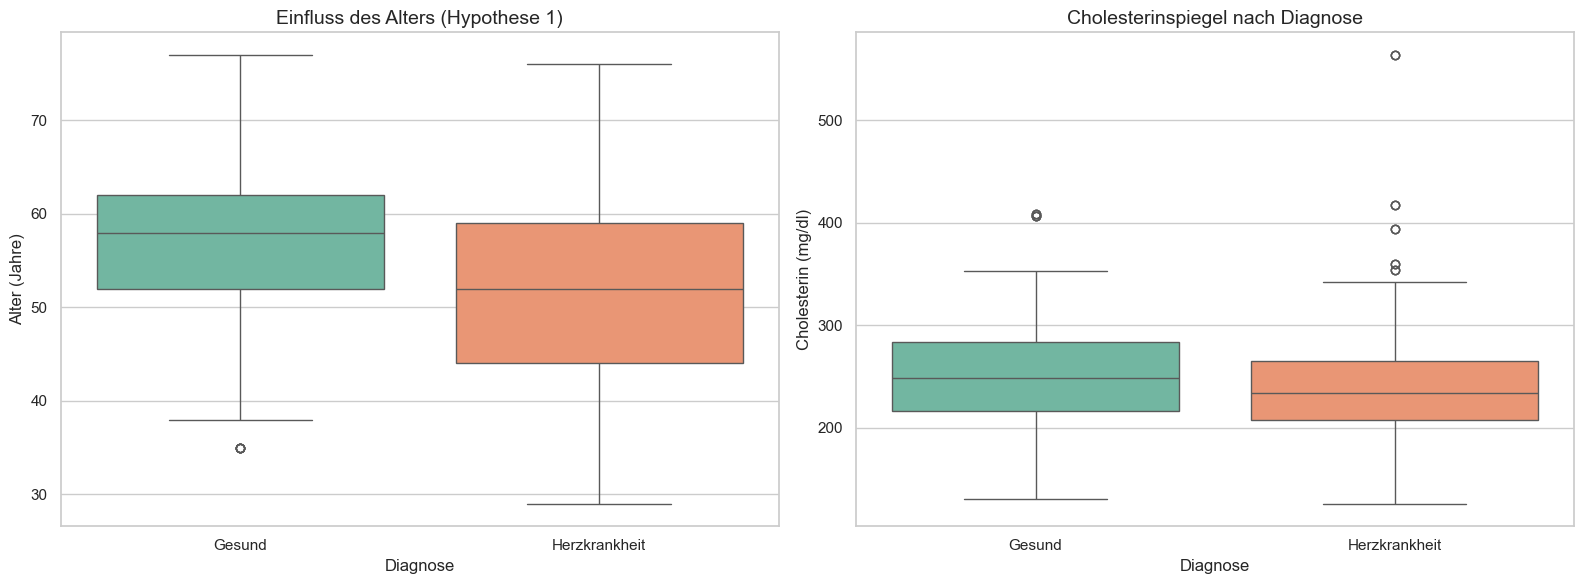

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Alter (Hypothese 1)
sns.boxplot(x='target', y='age', data=df_vis, palette='Set2', ax=axes[0])
axes[0].set_title('Einfluss des Alters (Hypothese 1)', fontsize=14)
axes[0].set_xlabel('Diagnose')
axes[0].set_ylabel('Alter (Jahre)')

# Plot 2: Cholesterin (für Hypothese 2)
sns.boxplot(x='target', y='chol', data=df_vis, palette='Set2', ax=axes[1])
axes[1].set_title('Cholesterinspiegel nach Diagnose', fontsize=14)
axes[1].set_xlabel('Diagnose')
axes[1].set_ylabel('Cholesterin (mg/dl)')

plt.tight_layout()
plt.show()

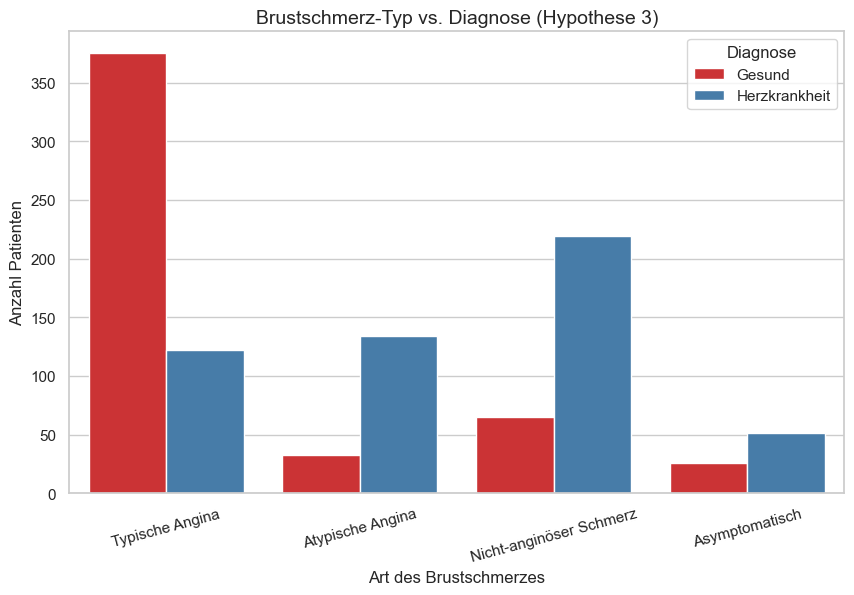

In [20]:
plt.figure(figsize=(10, 6))

# Wir schauen die Anteile an
sns.countplot(x='cp', hue='target', data=df_vis, palette='Set1')

plt.title('Brustschmerz-Typ vs. Diagnose (Hypothese 3)', fontsize=14)
plt.xlabel('Art des Brustschmerzes', fontsize=12)
plt.ylabel('Anzahl Patienten', fontsize=12)
plt.legend(title='Diagnose')
plt.xticks(rotation=15) # Text leicht drehen, falls er zu lang ist

plt.show()

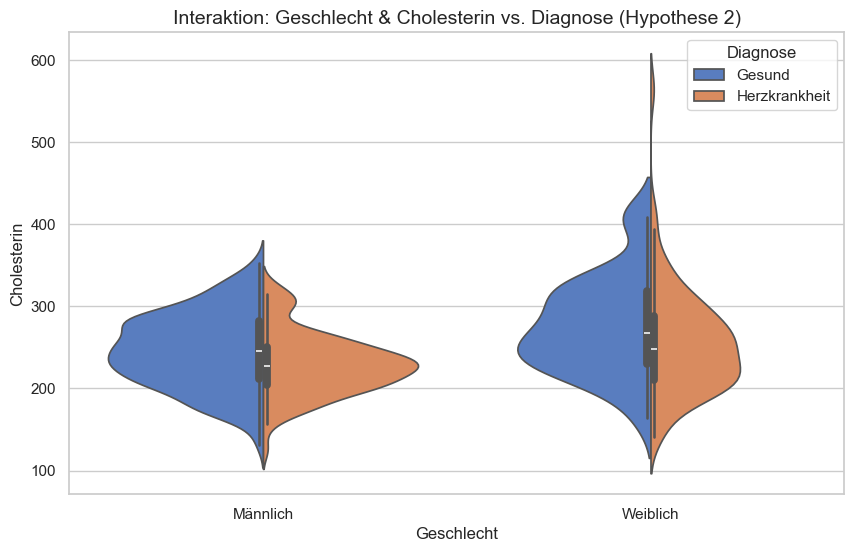

In [21]:
plt.figure(figsize=(10, 6))

# Ein Violinplot zeigt die Verteilung sehr schön
sns.violinplot(x='sex', y='chol', hue='target', data=df_vis, split=True, palette='muted')

plt.title('Interaktion: Geschlecht & Cholesterin vs. Diagnose (Hypothese 2)', fontsize=14)
plt.xlabel('Geschlecht', fontsize=12)
plt.ylabel('Cholesterin', fontsize=12)
plt.legend(title='Diagnose', loc='upper right')

plt.show()

In [22]:
# Wir gruppieren nach deiner Zielvariable und schauen uns den Anteil an Brustschmerzen an
check = df.groupby('target')['exang'].mean()
print(check)

target
0    0.549098
1    0.134981
Name: exang, dtype: float64


In [23]:
# Check: Welche Gruppe hat Brustschmerzen beim Sport (exang=1)?
check = df.groupby('target')['exang'].mean()
print("Anteil Patienten mit Sport-Angina pro Gruppe:")
print(check)

Anteil Patienten mit Sport-Angina pro Gruppe:
target
0    0.549098
1    0.134981
Name: exang, dtype: float64


### Mir der Richtigen Zuordnung der Zielvariable

C:\Users\jaegg\AppData\Local\Temp\ipykernel_20020\1905940597.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df_vis, palette='Set2')


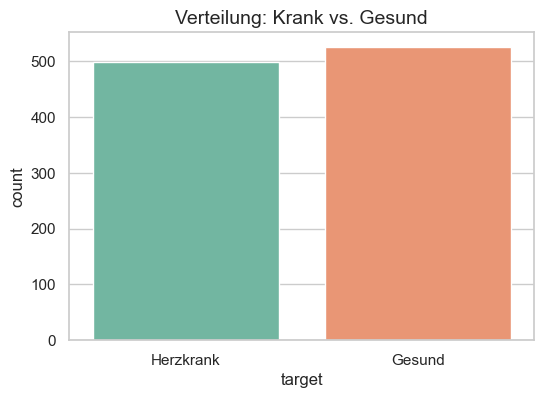

C:\Users\jaegg\AppData\Local\Temp\ipykernel_20020\1905940597.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='age', data=df_vis, palette='Set2')


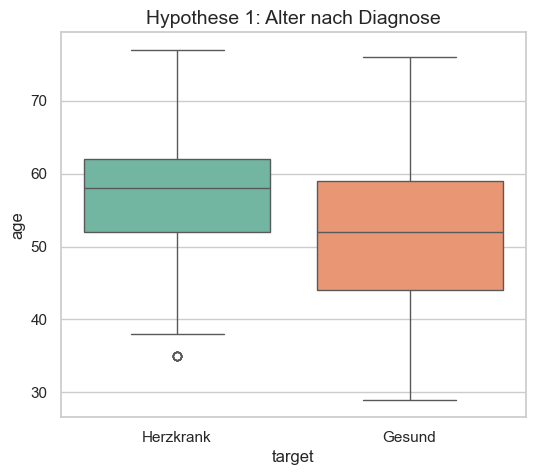

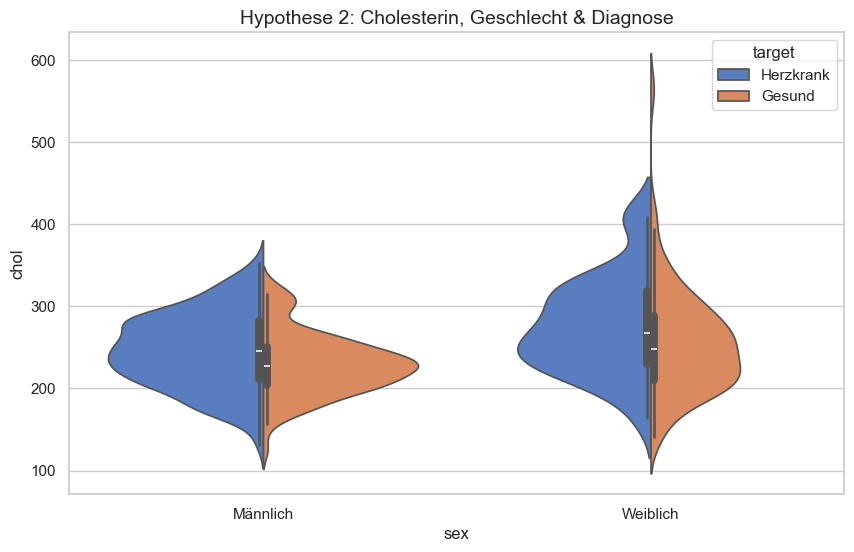

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Daten laden
df = pd.read_csv('heart.csv')

# --- 1. DATEN BEREINIGEN (Die "Kaggle-Falle" korrigieren) ---
# Basierend auf deiner Analyse (Alter & Angina) drehen wir die Bedeutung um:
# 0 -> Herzkrank
# 1 -> Gesund
df_vis = df.copy()
df_vis['target'] = df_vis['target'].map({0: 'Herzkrank', 1: 'Gesund'}) 

# Labels für Geschlecht und Schmerztyp lesbar machen
df_vis['sex'] = df_vis['sex'].map({1: 'Männlich', 0: 'Weiblich'})
df_vis['cp'] = df_vis['cp'].map({
    0: 'Typische Angina',
    1: 'Atypische Angina',
    2: 'Nicht-anginöser Schmerz',
    3: 'Asymptomatisch'
})

# Design setzen
sns.set_theme(style="whitegrid")

# --- 2. PLOTS ERSTELLEN ---

# Plot A: Verteilung der Zielvariable (Ist der Datensatz ausgeglichen?)
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df_vis, palette='Set2')
plt.title('Verteilung: Krank vs. Gesund', fontsize=14)
# Zahlen auf die Balken schreiben
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

# Plot B: Hypothese 1 (Alter) - Jetzt müsste "Herzkrank" ÄLTER sein
plt.figure(figsize=(6, 5))
sns.boxplot(x='target', y='age', data=df_vis, palette='Set2')
plt.title('Hypothese 1: Alter nach Diagnose', fontsize=14)
plt.show()

# Plot C: Hypothese 2 (Interaktion Cholesterin & Geschlecht)
plt.figure(figsize=(10, 6))
sns.violinplot(x='sex', y='chol', hue='target', data=df_vis, split=True, palette='muted')
plt.title('Hypothese 2: Cholesterin, Geschlecht & Diagnose', fontsize=14)
plt.show()

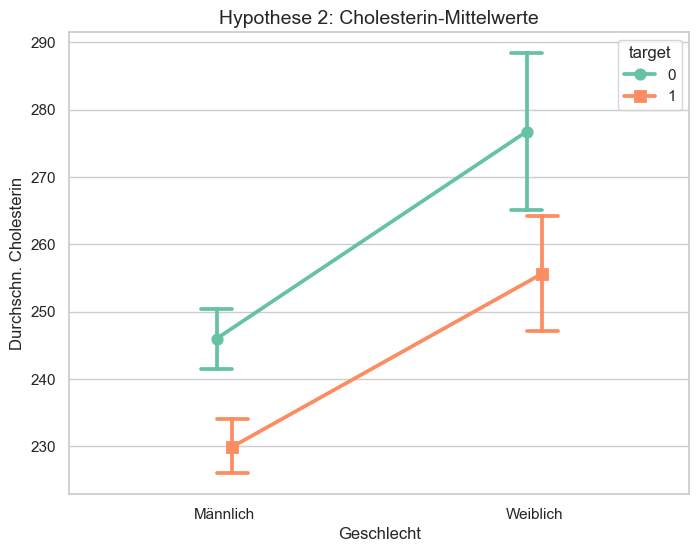

In [36]:
plt.figure(figsize=(8, 6))

# Pointplot: Zeigt den Mittelwert und das Vertrauensintervall
sns.pointplot(x='sex', y='chol', hue='target', data=df_vis, dodge=True, markers=['o', 's'], capsize=.1, palette='Set2')

plt.title('Hypothese 2: Cholesterin-Mittelwerte', fontsize=14)
plt.ylabel('Durchschn. Cholesterin')
plt.xlabel('Geschlecht')
plt.show()

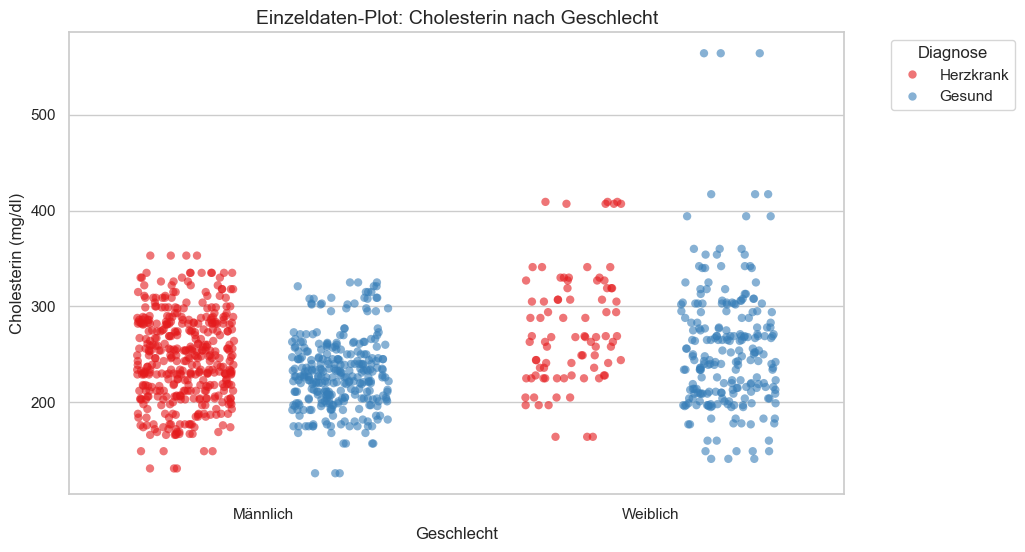

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Stripplot: Zeigt jeden einzelnen Patienten als Punkt
sns.stripplot(
    x='sex', 
    y='chol', 
    hue='target', 
    data=df_vis, 
    dodge=True,     # WICHTIG: Trennt die Gruppen (Gesund/Krank) nebeneinander
    jitter=0.25,    # Streut die Punkte seitlich, damit sie nicht überlappen
    alpha=0.6,      # Macht Punkte leicht transparent
    size=6,
    palette='Set1'
)

plt.title('Einzeldaten-Plot: Cholesterin nach Geschlecht', fontsize=14)
plt.ylabel('Cholesterin (mg/dl)')
plt.xlabel('Geschlecht')
plt.legend(title='Diagnose', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

C:\Users\jaegg\AppData\Local\Temp\ipykernel_20020\877081517.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='sex', data=df_vis, palette="Set2")


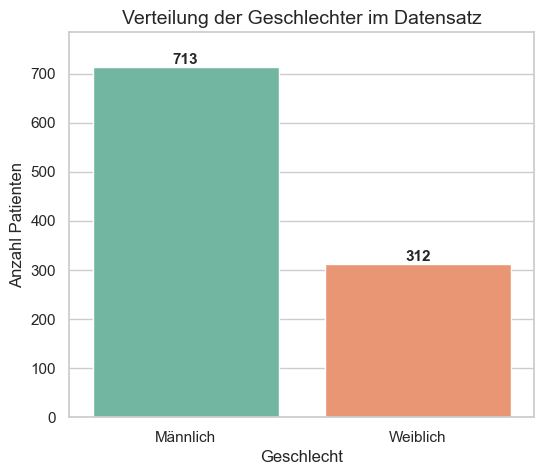

Anteil Männer: 69.6%
Anteil Frauen: 30.4%


In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Daten laden (falls noch nicht geladen)
df = pd.read_csv('heart.csv')

# Eine Kopie für die Visualisierung erstellen
df_vis = df.copy()

# Geschlecht lesbar machen (Standard: 1 = Mann, 0 = Frau)
df_vis['sex'] = df_vis['sex'].map({1: 'Männlich', 0: 'Weiblich'})

# Plot erstellen
plt.figure(figsize=(6, 5))
ax = sns.countplot(x='sex', data=df_vis, palette="Set2")

# Titel und Achsenbeschriftung
plt.title('Verteilung der Geschlechter im Datensatz', fontsize=14)
plt.xlabel('Geschlecht', fontsize=12)
plt.ylabel('Anzahl Patienten', fontsize=12)

# Zahlen direkt auf die Balken schreiben (damit man es sofort sieht)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')

# Y-Achse etwas höher machen, damit die Zahl oben Platz hat
plt.ylim(0, df_vis['sex'].value_counts().max() * 1.1)

plt.show()

# Berechnung der Prozentzahlen für deine Notizen
counts = df_vis['sex'].value_counts(normalize=True) * 100
print(f"Anteil Männer: {counts['Männlich']:.1f}%")
print(f"Anteil Frauen: {counts['Weiblich']:.1f}%")
